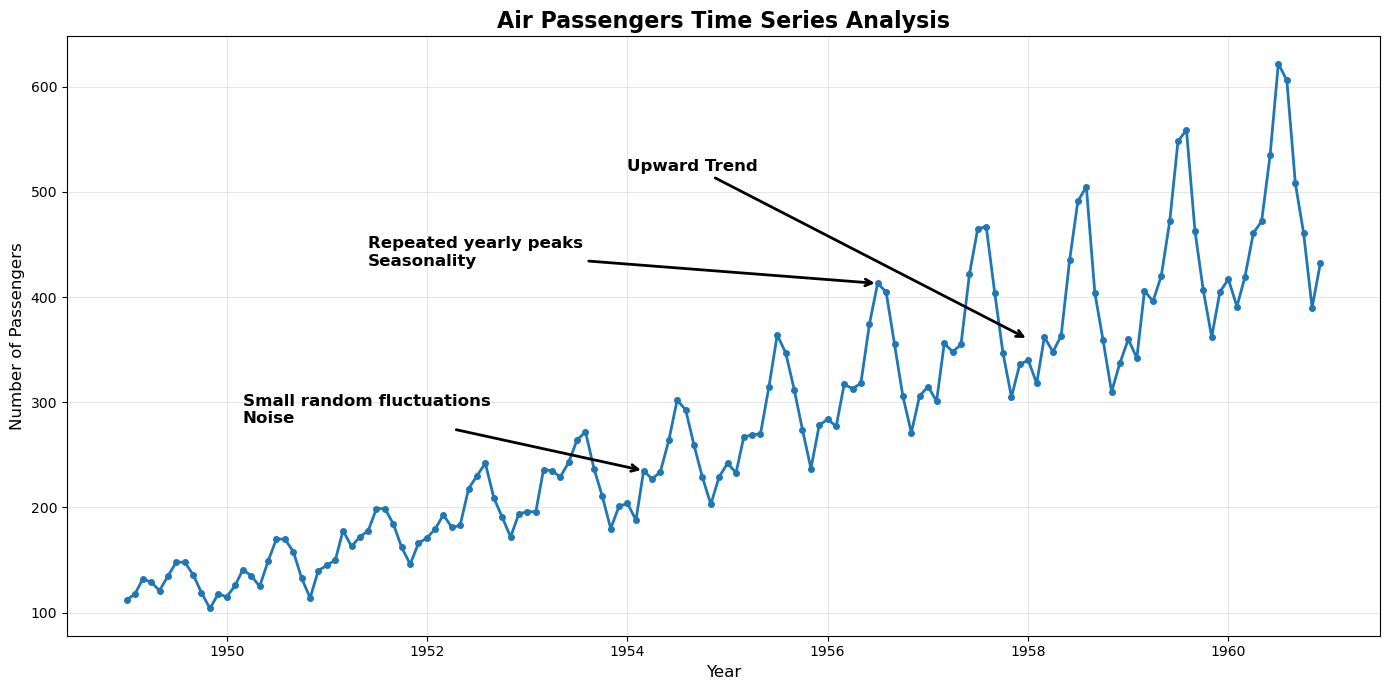

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

df['Month'] = pd.to_datetime(df['Month'])

plt.figure(figsize=(14, 7))
plt.plot(df['Month'], df['Passengers'], marker='o', linewidth=2, markersize=4)

plt.title("Air Passengers Time Series Analysis", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.grid(True, alpha=0.3)

# Trend annotation
plt.annotate(
    "Upward Trend",
    xy=(pd.Timestamp("1958-01-01"), 360),
    xytext=(pd.Timestamp("1954-01-01"), 520),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=12,
    fontweight="bold"
)

# Seasonality annotation
plt.annotate(
    "Repeated yearly peaks\nSeasonality",
    xy=(pd.Timestamp("1956-07-01"), 413),
    xytext=(pd.Timestamp("1951-06-01"), 430),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=12,
    fontweight="bold"
)

# Noise annotation
plt.annotate(
    "Small random fluctuations\nNoise",
    xy=(pd.Timestamp("1954-03-01"), 235),
    xytext=(pd.Timestamp("1950-03-01"), 280),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

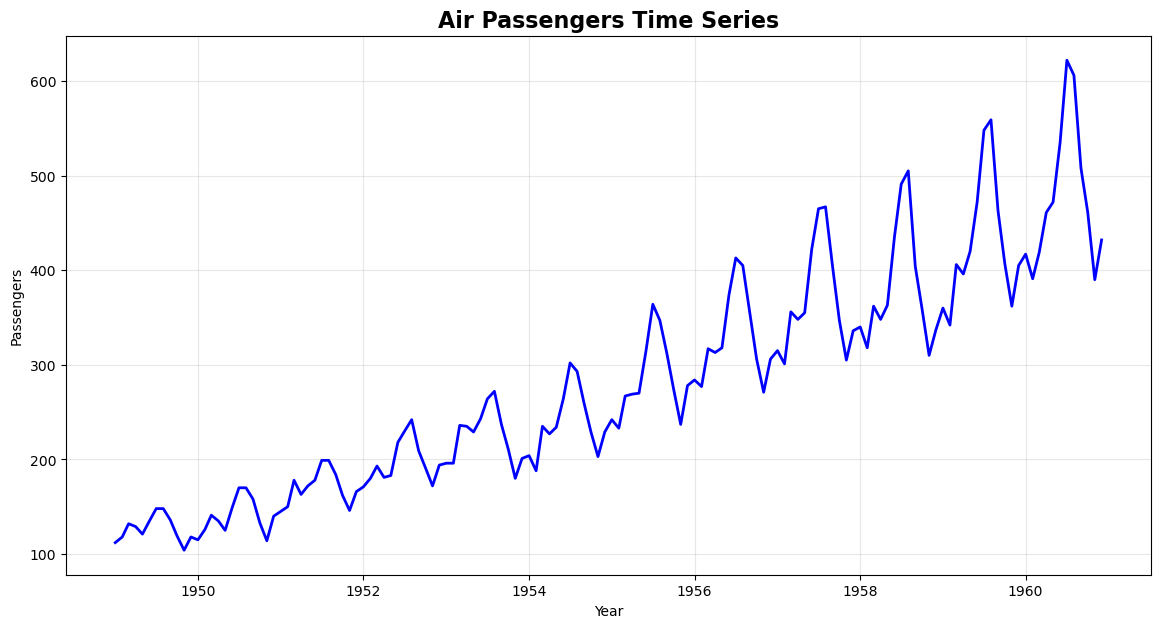

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])

plt.figure(figsize=(14,7))
plt.plot(df['Month'], df['Passengers'], color='blue', linewidth=2)

plt.title("Air Passengers Time Series", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True, alpha=0.3)

plt.show()

In [5]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


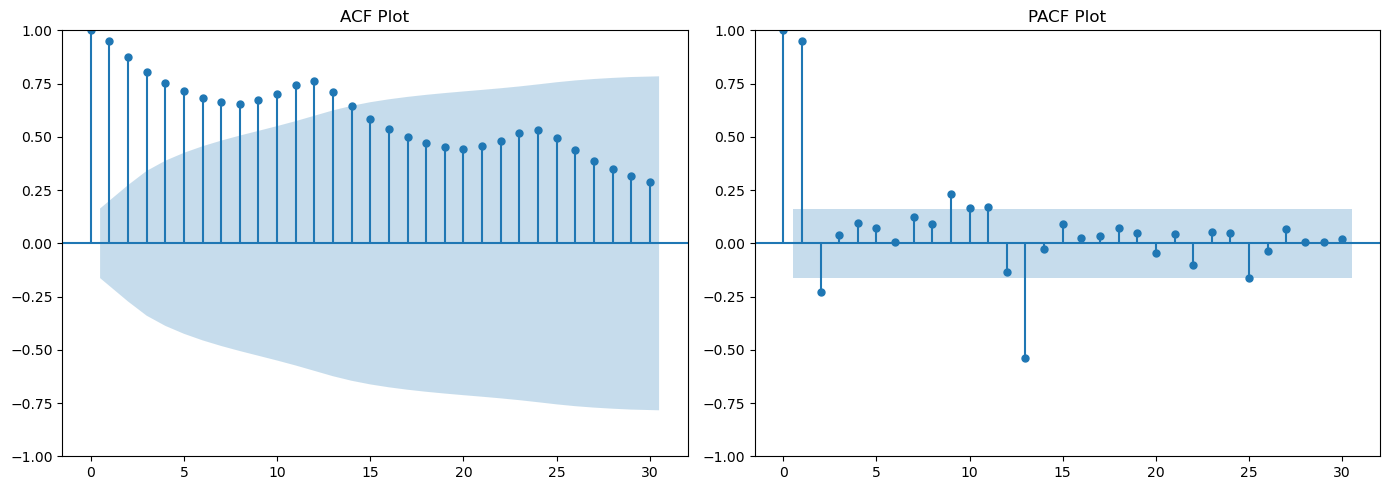

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# تحميل الداتا
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# تحويل التاريخ
df['Month'] = pd.to_datetime(df['Month'])

# استخراج القيم
data = df['Passengers']

# إنشاء الرسمتين
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ACF
plot_acf(data, ax=axes[0], lags=30)
axes[0].set_title("ACF Plot")

# PACF
plot_pacf(data, ax=axes[1], lags=30)
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

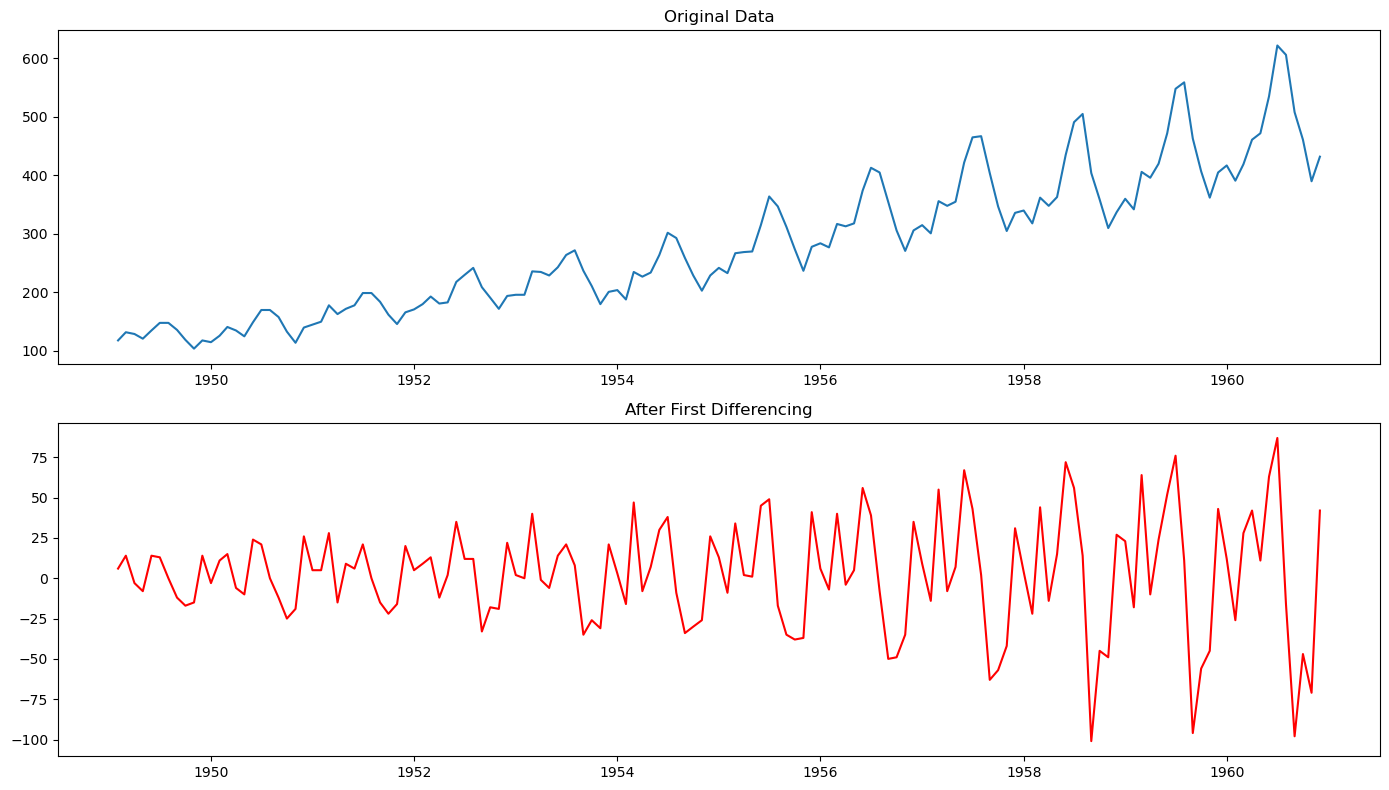

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf

# تحميل الداتا
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# تحويل التاريخ
df['Month'] = pd.to_datetime(df['Month'])

# First Differencing
df['Differenced'] = df['Passengers'].diff()

# حذف أول قيمة فارغة
df = df.dropna()

# رسم الداتا قبل وبعد
fig, axes = plt.subplots(2, 1, figsize=(14,8))

# قبل
axes[0].plot(df['Month'], df['Passengers'])
axes[0].set_title("Original Data")

# بعد
axes[1].plot(df['Month'], df['Differenced'], color='red')
axes[1].set_title("After First Differencing")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

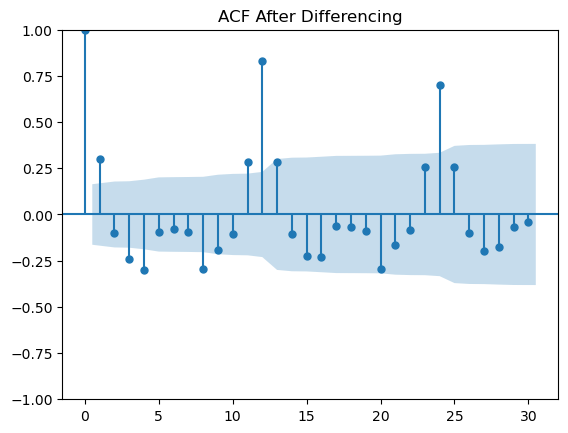

In [8]:
plt.figure(figsize=(10,5))

plot_acf(df['Differenced'], lags=30)

plt.title("ACF After Differencing")
plt.show()

In [9]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA


url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)


df['Month'] = pd.to_datetime(df['Month'])


data = df['Passengers']


model = ARIMA(data, order=(1,1,1))


model_fit = model.fit()


print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Tue, 12 May 2026   AIC                           1394.683
Time:                        19:22:53   BIC                           1403.571
Sample:                             0   HQIC                          1398.294
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

MAE: 85.25415593223154
RMSE: 97.49961964325676


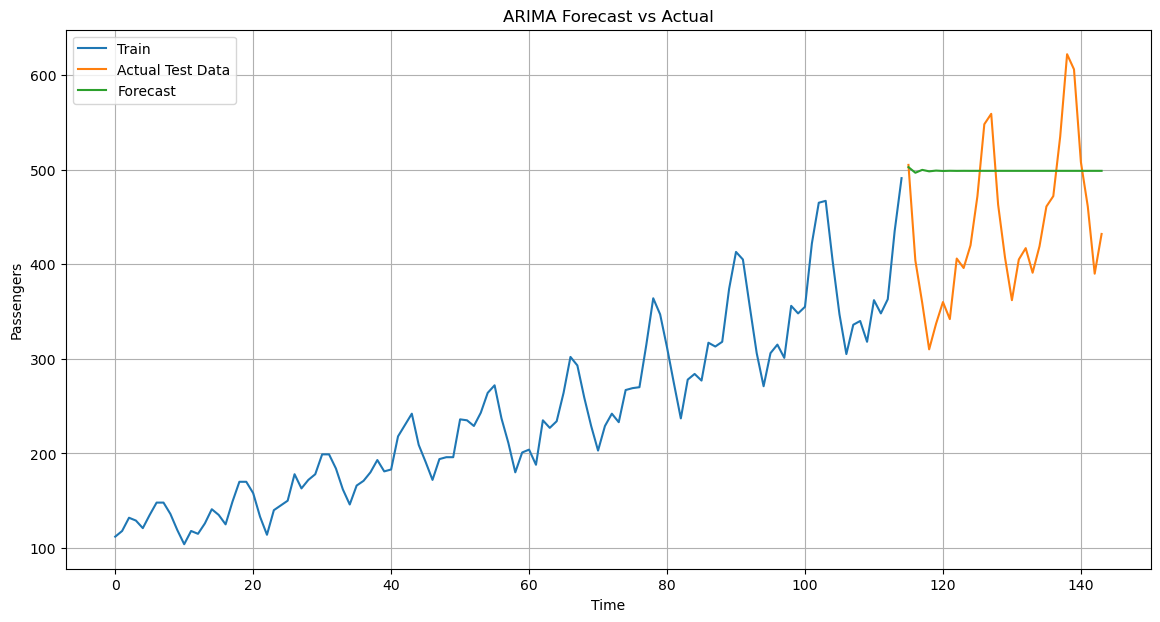

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# تحميل الداتا
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# تحويل التاريخ
df['Month'] = pd.to_datetime(df['Month'])

data = df['Passengers']

# تقسيم الداتا
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

# بناء الموديل
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# حساب المقاييس
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

# الرسم
plt.figure(figsize=(14,7))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.legend()
plt.grid(True)

plt.show()

MAE: 23.555494000687666
RMSE: 30.141771146708987


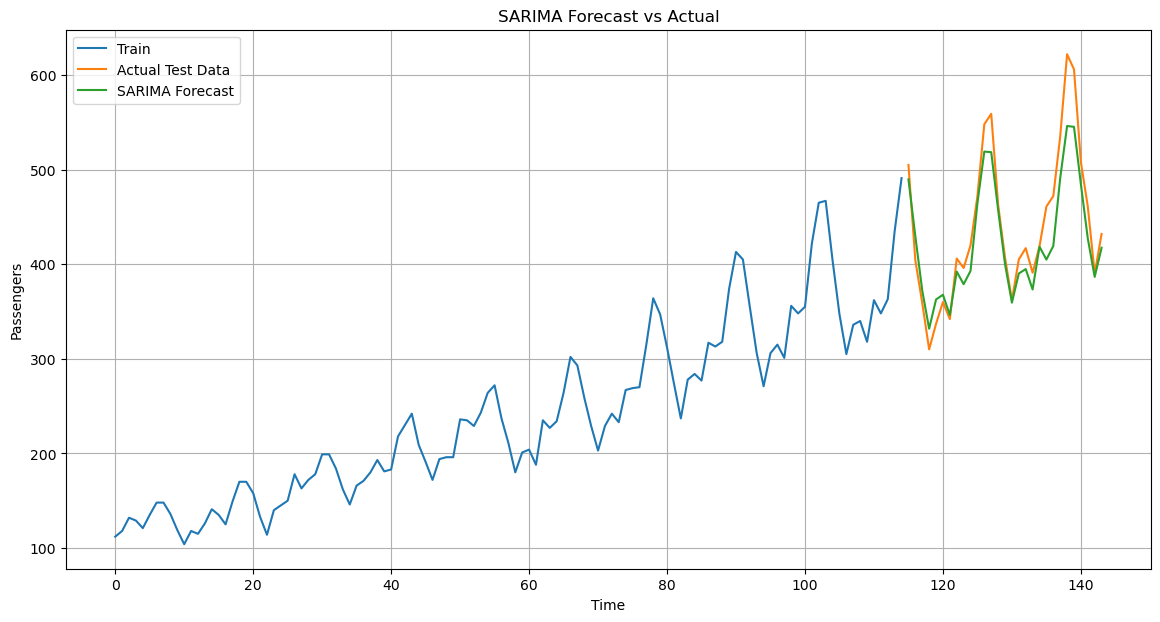

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df['Month'] = pd.to_datetime(df['Month'])

data = df['Passengers']


train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]


model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()


forecast = model_fit.forecast(steps=len(test))


mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)


plt.figure(figsize=(14,7))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Time")
plt.ylabel("Passengers")

plt.legend()
plt.grid(True)

plt.show()

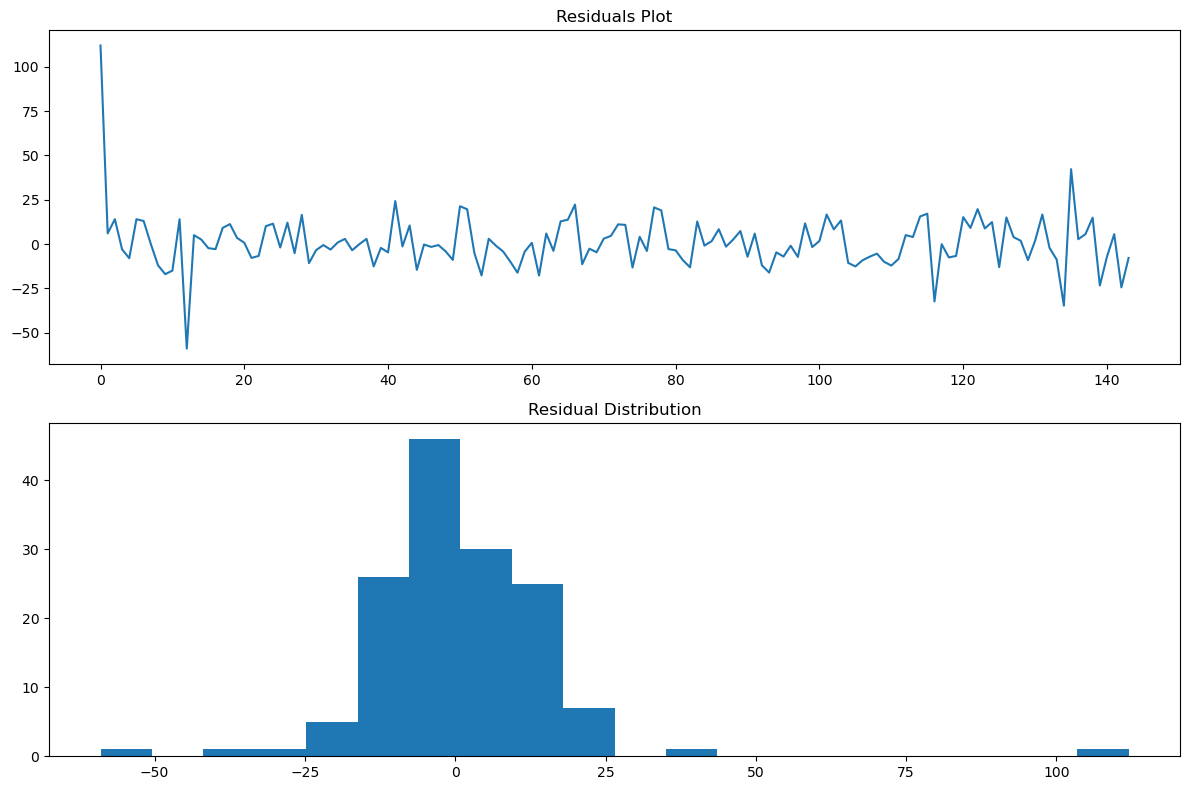

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# تحميل الداتا
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

data = df['Passengers']

# بناء موديل SARIMA
model = SARIMAX(
    data,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

# استخراج الـ residuals
residuals = model_fit.resid

# الرسومات
fig, axes = plt.subplots(2,1, figsize=(12,8))

# Residual Plot
axes[0].plot(residuals)
axes[0].set_title("Residuals Plot")

# Histogram
axes[1].hist(residuals, bins=20)
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [14]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


MAE: 34.22
RMSE: 41.92


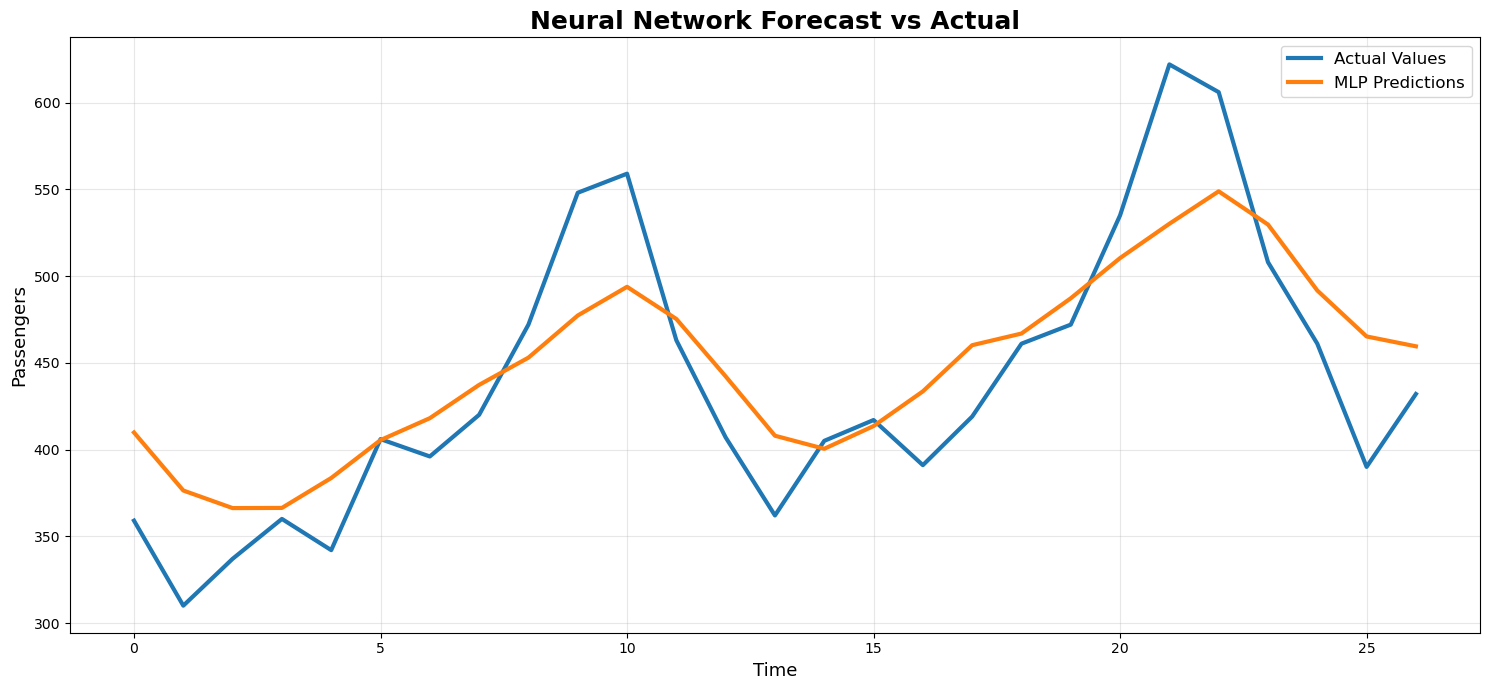

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# =========================
# Load Dataset
# =========================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# =========================
# Prepare Data
# =========================

data = df['Passengers'].values.reshape(-1,1)

# Scaling
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

# Create sequences
X = []
y = []

window_size = 12

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Train/Test Split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# =========================
# Build Neural Network
# =========================

model = MLPRegressor(
    hidden_layer_sizes=(100,50),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Inverse Scaling
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Metrics
mae = mean_absolute_error(y_test_actual, predictions)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# =========================
# Professional Plot
# =========================

plt.figure(figsize=(15,7))

# Actual
plt.plot(
    y_test_actual,
    label='Actual Values',
    linewidth=3,
    color='#1f77b4'
)

# Predictions
plt.plot(
    predictions,
    label='MLP Predictions',
    linewidth=3,
    color='#ff7f0e'
)

# Styling
plt.title(
    "Neural Network Forecast vs Actual",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Time", fontsize=13)
plt.ylabel("Passengers", fontsize=13)

plt.grid(True, alpha=0.3)

plt.legend(fontsize=12)

plt.tight_layout()

plt.show()